In [1]:
#setup and load data:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("books_data.csv")

# Re-apply the same category cleanup we did in Task 2
df.loc[df["Category"].isin(["Add a comment", "Default"]), "Category"] = "Uncategorized"

df.head()

,Title,Price (GBP),Price (INR),Rating,Stock Count,Category
0,A Light in the Attic,51.77,5435.85,3,22,Poetry
1,Tipping the Velvet,53.74,5642.70,1,20,Historical Fiction
2,Soumission,50.10,5260.50,1,20,Fiction
3,Sharp Objects,47.82,5021.10,4,20,Mystery
4,Sapiens: A Brief History of Humankind,54.23,5694.15,5,20,History


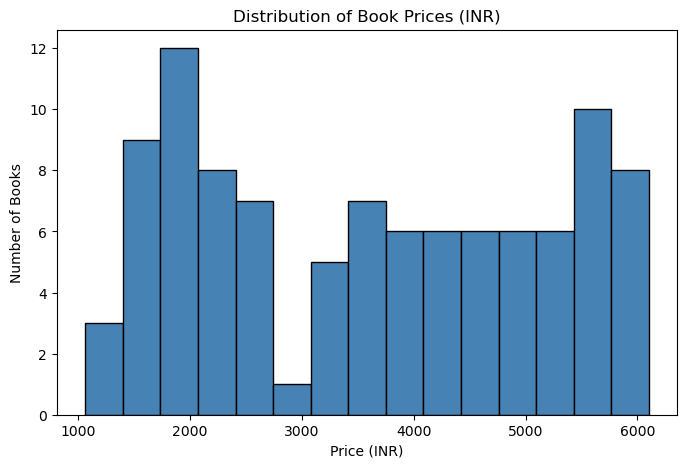

In [2]:
#Price Distribution (Histogram)
plt.figure(figsize=(8, 5))
plt.hist(df["Price (INR)"], bins=15, color="steelblue", edgecolor="black")
plt.title("Distribution of Book Prices (INR)")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Books")
plt.show()

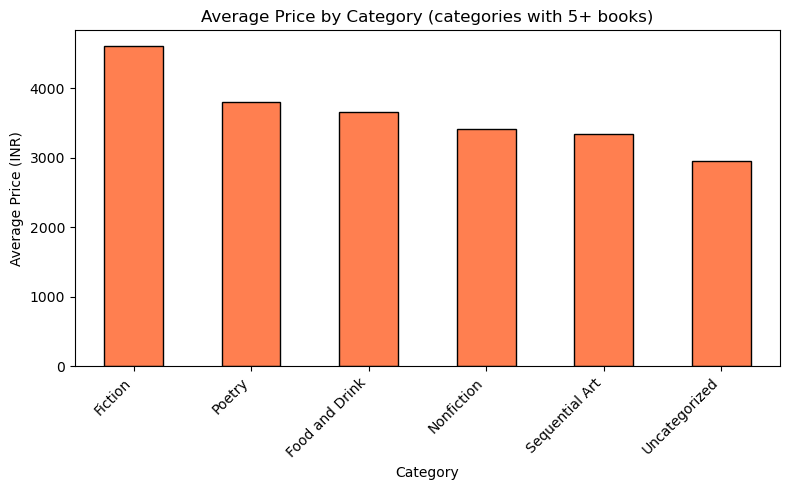

In [3]:
# Filter to categories with at least 5 books
category_counts = df["Category"].value_counts()
reliable_categories = category_counts[category_counts >= 5].index

filtered_df = df[df["Category"].isin(reliable_categories)]

avg_price = filtered_df.groupby("Category")["Price (INR)"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_price.plot(kind="bar", color="coral", edgecolor="black")
plt.title("Average Price by Category (categories with 5+ books)")
plt.xlabel("Category")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

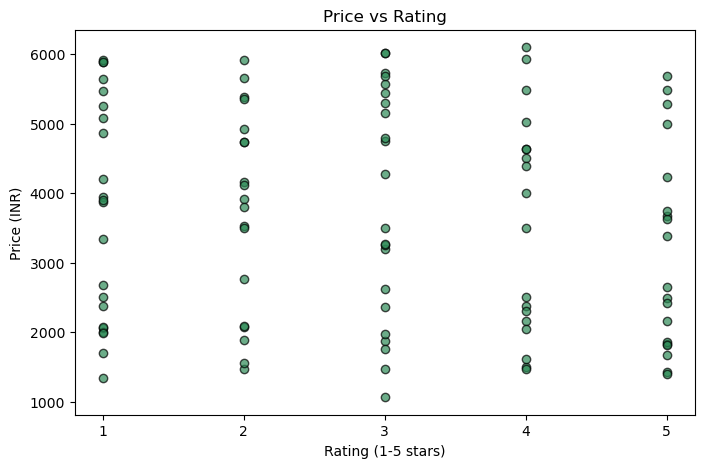

In [4]:
#Price vs Rating (Scatter Plot)
plt.figure(figsize=(8, 5))
plt.scatter(df["Rating"], df["Price (INR)"], color="seagreen", alpha=0.7, edgecolor="black")
plt.title("Price vs Rating")
plt.xlabel("Rating (1-5 stars)")
plt.ylabel("Price (INR)")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

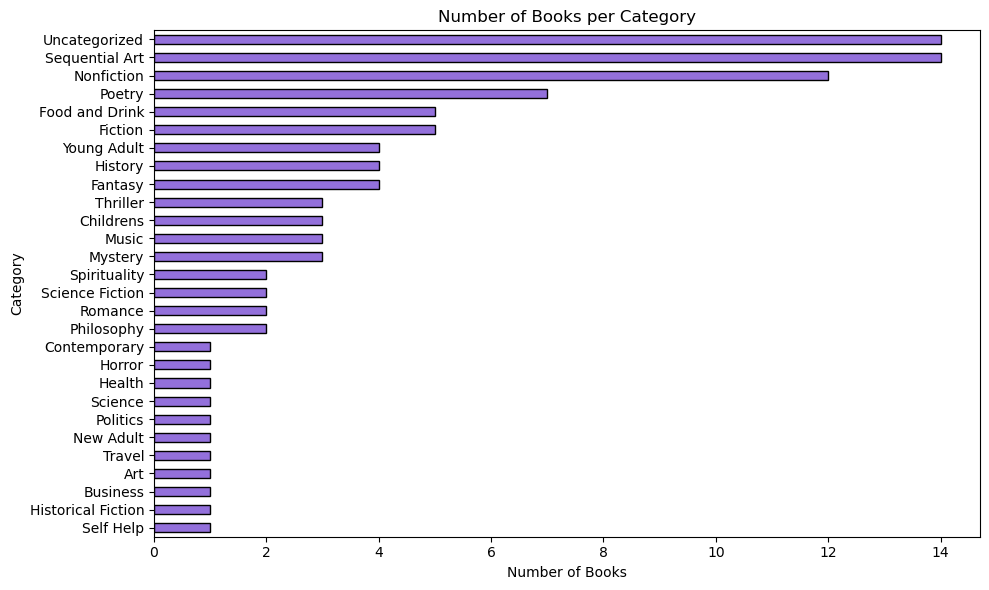

In [5]:
#Category Distribution(showing the imbalance)
plt.figure(figsize=(10, 6))
df["Category"].value_counts().plot(kind="barh", color="mediumpurple", edgecolor="black")
plt.title("Number of Books per Category")
plt.xlabel("Number of Books")
plt.ylabel("Category")
plt.gca().invert_yaxis()  # so the largest category shows at top
plt.tight_layout()
plt.show()

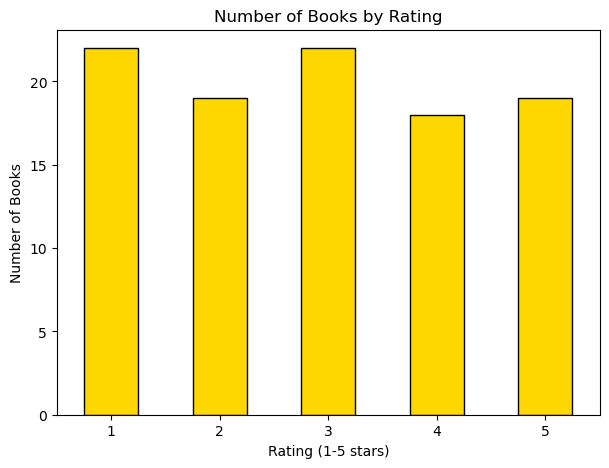

In [6]:
#Rating Distribution
plt.figure(figsize=(7, 5))
df["Rating"].value_counts().sort_index().plot(kind="bar", color="gold", edgecolor="black")
plt.title("Number of Books by Rating")
plt.xlabel("Rating (1-5 stars)")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.show()